# `v_n` - `epsilon_n` 多元线性回归分析

这个 notebook 读取 `response-test-023` 的 independent-pools fluctuating 样本，并把表观交叉响应拆成两部分：

\[
v_{2|\Psi_2}=c_2+k_{22}\epsilon_2+k_{23}\epsilon_3,\qquad
v_{3|\Psi_3}=c_3+k_{32}\epsilon_2+k_{33}\epsilon_3.
\]

其中 `k23` 和 `k32` 是在固定另一个 eccentricity 后的条件交叉响应估计。它们用于区分真实 cross-harmonic response 和由 `corr(eps2, eps3)` 诱导出来的 raw `v2-eps3` / `v3-eps2` 斜率。


如果输入 ROOT 文件包含 `v2_lab_x` / `v2_lab_y`，notebook 会额外做 lab-frame 二阶分量的多元回归诊断。这个诊断用于固定坐标系下的符号和旋转检查，不替代 participant-plane response 的主结论。


## 环境与输入

推荐使用本仓库已有的 `root_notebook` conda 环境：

```bash
conda activate root_notebook
```

默认输入组只包含 independent-pools 的四个 023 fluctuating 输出：`dense`、`dense_mix`、`newrap` 和 `ellipse`。若某个 ROOT 文件尚未生成，读取阶段会跳过并打印原因。


In [1]:
# Load the uproot-based analysis stack. The notebook intentionally does not depend on PyROOT.
from pathlib import Path
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import uproot

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.precision", 6)


In [2]:
# Resolve the repository root whether the notebook is opened from repo root or notebooks/.
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DEFAULT_INPUT_GROUP_CANDIDATES = {
    "response_023_fluct_independent_pools": {
        "title": "023 independent-pools fluctuating response-test",
        "files": [
            (PROJECT_ROOT / "qa" / "test_023_dense_fluct_independent_pools.root", "dense"),
            (PROJECT_ROOT / "qa" / "test_023_dense_mix_fluct_independent_pools.root", "dense_mix"),
            (PROJECT_ROOT / "qa" / "test_023_dense_newrap_fluct_independent_pools.root", "newrap"),
            (PROJECT_ROOT / "qa" / "test_023_ellipse_fluct_independent_pools.root", "ellipse"),
        ],
    },
}
INPUT_FILE_GROUPS = DEFAULT_INPUT_GROUP_CANDIDATES

PLOT_RAW_SCATTER = False
PROFILE_BINS = 14
SCATTER_MAX_POINTS = 20000


def normalise_input_files(entries, *, group_key):
    specs = []
    seen_labels = set()
    for entry in entries:
        if isinstance(entry, (str, Path)):
            path = Path(entry)
            label = path.stem
        else:
            path = Path(entry[0])
            label = str(entry[1]) if len(entry) > 1 else path.stem

        if not path.is_absolute():
            path = PROJECT_ROOT / path
        path = path.resolve()
        if not path.exists():
            print(f"[skip] {group_key}/{label}: file does not exist: {path}")
            continue
        if label in seen_labels:
            raise ValueError(f"Duplicate input label {label!r} in group {group_key!r}.")
        seen_labels.add(label)
        specs.append({"group_key": group_key, "path": path, "label": label})
    return specs


# Normalize user-editable group definitions into a list consumed by all downstream cells.
def normalise_input_groups(group_definitions):
    groups = []
    for group_key, group_definition in group_definitions.items():
        if isinstance(group_definition, dict):
            group_title = group_definition.get("title", group_key)
            entries = group_definition.get("files", [])
        else:
            group_title = group_key
            entries = group_definition

        specs = normalise_input_files(entries, group_key=group_key)
        if not specs:
            print(f"[skip group] {group_key}: no existing ROOT input files were configured.")
            continue
        groups.append({"key": group_key, "title": group_title, "input_files": specs})

    if not groups:
        raise FileNotFoundError("No configured independent-pools ROOT files exist yet; run the matching cfg files first.")
    return groups


analysis_groups = normalise_input_groups(INPUT_FILE_GROUPS)
print(f"PROJECT_ROOT = {PROJECT_ROOT}")
for group in analysis_groups:
    print(f"[{group['key']}] {group['title']}")
    for spec in group["input_files"]:
        print(f"  {spec['label']}: {spec['path']}")


PROJECT_ROOT = /Users/allenzhou/Research_software/Blast_wave
[response_023_fluct_independent_pools] 023 independent-pools fluctuating response-test
  dense: /Users/allenzhou/Research_software/Blast_wave/qa/test_023_dense_fluct_independent_pools.root
  dense_mix: /Users/allenzhou/Research_software/Blast_wave/qa/test_023_dense_mix_fluct_independent_pools.root
  newrap: /Users/allenzhou/Research_software/Blast_wave/qa/test_023_dense_newrap_fluct_independent_pools.root
  ellipse: /Users/allenzhou/Research_software/Blast_wave/qa/test_023_ellipse_fluct_independent_pools.root


## 读取 `events` 树

本分析只使用事件级分支。`eps2/eps3` 是 measured initial geometry，`v2_wrt_psi2/v3_wrt_psi3` 是末态 Q-vector 相对初态平面的投影。


In [3]:
# Inspect top-level objects and verify that the event tree and required branches are present.
REQUIRED_BRANCHES = ["eps2", "eps3", "v2_wrt_psi2", "v3_wrt_psi3"]
OPTIONAL_BRANCHES = [
    "event_id", "centrality", "Npart", "Nch", "v2", "v3", "v2_lab_x", "v2_lab_y",
    "eps2_f", "chi2", "R_rms_init", "r2_0", "r2_f", "r2_ratio",
    "geo_a2", "geo_a3", "geo_r2x", "geo_r2y", "geo_r3", "geo_sigma3",
]

inspection_rows = []
for group in analysis_groups:
    for spec in group["input_files"]:
        try:
            with uproot.open(str(spec["path"])) as root_file:
                if "events" not in root_file:
                    raise KeyError("missing required 'events' tree")
                branches = sorted(root_file["events"].keys())
                missing = [branch for branch in REQUIRED_BRANCHES if branch not in branches]
                if missing:
                    raise KeyError(f"missing required event branches: {missing}")
                inspection_rows.append({
                    "analysis_group": group["key"],
                    "label": spec["label"],
                    "path": str(spec["path"]),
                    "n_event_branches": len(branches),
                    "status": "ok",
                })
        except Exception as exc:
            inspection_rows.append({
                "analysis_group": group["key"],
                "label": spec["label"],
                "path": str(spec["path"]),
                "n_event_branches": 0,
                "status": f"ERROR: {exc}",
            })

inspection_table = pd.DataFrame(inspection_rows)
display(inspection_table)


,analysis_group,label,path,n_event_branches,status
0,response_023_fluct_independent_pools,dense,/Users/allenzhou/Research_software/Blast_wave/...,31,ok
1,response_023_fluct_independent_pools,dense_mix,/Users/allenzhou/Research_software/Blast_wave/...,31,ok
2,response_023_fluct_independent_pools,newrap,/Users/allenzhou/Research_software/Blast_wave/...,31,ok
3,response_023_fluct_independent_pools,ellipse,/Users/allenzhou/Research_software/Blast_wave/...,31,ok


In [4]:
# Read each input file into a pandas event table and keep only groups with valid ROOT inputs.
def read_event_table(input_spec):
    with uproot.open(str(input_spec["path"])) as root_file:
        event_tree = root_file["events"]
        event_branches = set(event_tree.keys())
        missing_required = [branch for branch in REQUIRED_BRANCHES if branch not in event_branches]
        if missing_required:
            raise KeyError(f"missing required event branches: {missing_required}")

        branches_to_read = []
        for branch in REQUIRED_BRANCHES + OPTIONAL_BRANCHES:
            if branch in event_branches and branch not in branches_to_read:
                branches_to_read.append(branch)
        table = event_tree.arrays(branches_to_read, library="pd")
        table["analysis_group"] = input_spec["group_key"]
        table["source_label"] = input_spec["label"]
        return table


event_tables_by_group = {}
valid_analysis_groups = []
read_rows = []
for group in analysis_groups:
    group_key = group["key"]
    group_event_tables = {}
    valid_input_files = []
    for spec in group["input_files"]:
        try:
            table = read_event_table(spec)
        except Exception as exc:
            print(f"[skip] {group_key}/{spec['label']}: {exc}")
            continue
        group_event_tables[spec["label"]] = table
        valid_input_files.append(spec)
        read_rows.append({
            "analysis_group": group_key,
            "label": spec["label"],
            "path": str(spec["path"]),
            "n_events": len(table),
            "n_columns": len(table.columns),
        })

    if valid_input_files:
        event_tables_by_group[group_key] = group_event_tables
        valid_analysis_groups.append({**group, "input_files": valid_input_files})

if not valid_analysis_groups:
    raise RuntimeError("No configured ROOT files could be read with the required event-level response branches.")

analysis_groups = valid_analysis_groups
first_group_key = analysis_groups[0]["key"]
read_summary = pd.DataFrame(read_rows)
display(read_summary)


,analysis_group,label,path,n_events,n_columns
0,response_023_fluct_independent_pools,dense,/Users/allenzhou/Research_software/Blast_wave/...,5000,26
1,response_023_fluct_independent_pools,dense_mix,/Users/allenzhou/Research_software/Blast_wave/...,5000,26
2,response_023_fluct_independent_pools,newrap,/Users/allenzhou/Research_software/Blast_wave/...,5000,26
3,response_023_fluct_independent_pools,ellipse,/Users/allenzhou/Research_software/Blast_wave/...,5000,26


In [5]:
# Configure event-level cuts and optional weights in one place.
CENTRALITY_RANGE = None
NCH_MIN = None
EPSILON_MIN = 0.0
WEIGHT_COLUMN = None


def select_events(data: pd.DataFrame) -> pd.DataFrame:
    selected = data.copy()
    finite_columns = ["eps2", "eps3", "v2_wrt_psi2", "v3_wrt_psi3"]
    finite_mask = np.ones(len(selected), dtype=bool)
    for column in finite_columns:
        finite_mask &= np.isfinite(selected[column].to_numpy(dtype=float))
    selected = selected.loc[finite_mask]

    if CENTRALITY_RANGE is not None and "centrality" in selected:
        low, high = CENTRALITY_RANGE
        selected = selected[(selected["centrality"] >= low) & (selected["centrality"] < high)]

    if NCH_MIN is not None and "Nch" in selected:
        selected = selected[selected["Nch"] >= NCH_MIN]

    if EPSILON_MIN > 0.0:
        selected = selected[(selected["eps2"] >= EPSILON_MIN) & (selected["eps3"] >= EPSILON_MIN)]

    return selected.reset_index(drop=True)


selected_events_by_group = {}
selection_rows = []
for group in analysis_groups:
    group_key = group["key"]
    selected_events_for_group = {}
    for spec in group["input_files"]:
        label = spec["label"]
        selected = select_events(event_tables_by_group[group_key][label])
        selected_events_for_group[label] = selected
        selection_rows.append({
            "analysis_group": group_key,
            "label": label,
            "input_events": len(event_tables_by_group[group_key][label]),
            "selected_events": len(selected),
        })
    selected_events_by_group[group_key] = selected_events_for_group

selection_summary = pd.DataFrame(selection_rows)
display(selection_summary)


,analysis_group,label,input_events,selected_events
0,response_023_fluct_independent_pools,dense,5000,5000
1,response_023_fluct_independent_pools,dense_mix,5000,5000
2,response_023_fluct_independent_pools,newrap,5000,5000
3,response_023_fluct_independent_pools,ellipse,5000,5000


## 回归 helper

`linear_fit` 给出普通一维斜率；`multivariate_fit` 同时拟合 `eps2` 和 `eps3`，因此交叉系数是条件斜率。`residualize` 用于画 Frisch-Waugh-Lovell 形式的 partial-regression 图。


In [6]:
# Shared regression utilities with optional event weights.
def weights_for(data: pd.DataFrame):
    if WEIGHT_COLUMN is None:
        return None
    if WEIGHT_COLUMN not in data:
        raise KeyError(f"WEIGHT_COLUMN={WEIGHT_COLUMN!r} is not present in the events table.")
    return data[WEIGHT_COLUMN].to_numpy(dtype=float)


def prepare_regression_arrays(data: pd.DataFrame, columns, weights=None):
    arrays = [data[column].to_numpy(dtype=float) for column in columns]
    mask = np.ones(len(data), dtype=bool)
    for array in arrays:
        mask &= np.isfinite(array)
    if weights is not None:
        w = np.asarray(weights, dtype=float)
        mask &= np.isfinite(w) & (w > 0.0)
        w = w[mask]
    else:
        w = np.ones(np.count_nonzero(mask), dtype=float)
    return [array[mask] for array in arrays], w


# Ordinary or weighted least squares for one y column against one x column.
def linear_fit(x_values, y_values, weights=None, *, intercept=True):
    x = np.asarray(x_values, dtype=float)
    y = np.asarray(y_values, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    if weights is not None:
        w = np.asarray(weights, dtype=float)
        mask &= np.isfinite(w) & (w > 0.0)
        w = w[mask]
    else:
        w = np.ones(np.count_nonzero(mask), dtype=float)
    x = x[mask]
    y = y[mask]
    if x.size < (2 if intercept else 1):
        raise ValueError("Not enough finite points for linear regression.")

    design = np.column_stack([np.ones_like(x), x]) if intercept else x[:, None]
    sqrt_w = np.sqrt(w)
    weighted_design = design * sqrt_w[:, None]
    weighted_y = y * sqrt_w
    beta, *_ = np.linalg.lstsq(weighted_design, weighted_y, rcond=None)
    fitted = design @ beta
    residuals = y - fitted

    n_points = x.size
    n_params = design.shape[1]
    dof = max(n_points - n_params, 0)
    ss_res = float(np.sum(w * residuals * residuals))
    y_mean = float(np.average(y, weights=w))
    ss_tot = float(np.sum(w * (y - y_mean) ** 2))
    r2 = 1.0 - ss_res / ss_tot if ss_tot > 0.0 else np.nan
    normal_matrix = weighted_design.T @ weighted_design
    sigma2 = ss_res / dof if dof > 0 else np.nan
    covariance = np.linalg.pinv(normal_matrix) * sigma2 if np.isfinite(sigma2) else np.full((n_params, n_params), np.nan)
    stderr = np.sqrt(np.diag(covariance))
    pearson_r = float(np.corrcoef(x, y)[0, 1]) if n_points > 1 and np.std(x) > 0.0 and np.std(y) > 0.0 else np.nan

    if intercept:
        return {
            "n": int(n_points), "intercept": float(beta[0]), "intercept_stderr": float(stderr[0]),
            "slope": float(beta[1]), "slope_stderr": float(stderr[1]), "r2": r2,
            "pearson_r": pearson_r, "rmse": math.sqrt(ss_res / n_points),
            "residuals": residuals, "fitted": fitted,
        }
    return {
        "n": int(n_points), "intercept": 0.0, "intercept_stderr": np.nan,
        "slope": float(beta[0]), "slope_stderr": float(stderr[0]), "r2": r2,
        "pearson_r": pearson_r, "rmse": math.sqrt(ss_res / n_points),
        "residuals": residuals, "fitted": fitted,
    }


# Fit y = c + beta_eps2 * eps2 + beta_eps3 * eps3. Coefficients are conditional slopes.
def multivariate_fit(data: pd.DataFrame, response: str, predictors=("eps2", "eps3"), weights=None):
    arrays, w = prepare_regression_arrays(data, [*predictors, response], weights=weights)
    *predictor_arrays, y = arrays
    if y.size < len(predictors) + 1:
        raise ValueError("Not enough finite points for multivariate regression.")

    design = np.column_stack([np.ones_like(y), *predictor_arrays])
    sqrt_w = np.sqrt(w)
    weighted_design = design * sqrt_w[:, None]
    weighted_y = y * sqrt_w
    beta, *_ = np.linalg.lstsq(weighted_design, weighted_y, rcond=None)
    fitted = design @ beta
    residuals = y - fitted

    n_points = y.size
    n_params = design.shape[1]
    dof = max(n_points - n_params, 0)
    ss_res = float(np.sum(w * residuals * residuals))
    y_mean = float(np.average(y, weights=w))
    ss_tot = float(np.sum(w * (y - y_mean) ** 2))
    r2 = 1.0 - ss_res / ss_tot if ss_tot > 0.0 else np.nan
    normal_matrix = weighted_design.T @ weighted_design
    sigma2 = ss_res / dof if dof > 0 else np.nan
    covariance = np.linalg.pinv(normal_matrix) * sigma2 if np.isfinite(sigma2) else np.full((n_params, n_params), np.nan)
    stderr = np.sqrt(np.diag(covariance))

    return {
        "n": int(n_points), "intercept": float(beta[0]), "intercept_stderr": float(stderr[0]),
        "coefficients": {name: float(value) for name, value in zip(predictors, beta[1:])},
        "stderr": {name: float(value) for name, value in zip(predictors, stderr[1:])},
        "r2": r2, "rmse": math.sqrt(ss_res / n_points), "residuals": residuals,
        "fitted": fitted, "predictor_values": {name: value for name, value in zip(predictors, predictor_arrays)},
        "response_values": y,
    }


# Remove the linear effect of control_columns from target_column; useful for partial-regression plots.
def residualize(data: pd.DataFrame, target_column: str, control_columns, weights=None):
    arrays, w = prepare_regression_arrays(data, [*control_columns, target_column], weights=weights)
    *control_arrays, target = arrays
    design = np.column_stack([np.ones_like(target), *control_arrays])
    sqrt_w = np.sqrt(w)
    beta, *_ = np.linalg.lstsq(design * sqrt_w[:, None], target * sqrt_w, rcond=None)
    return target - design @ beta


def binned_profile(x_values, y_values, *, bins=12):
    x = np.asarray(x_values, dtype=float)
    y = np.asarray(y_values, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]
    if x.size == 0 or np.nanmin(x) == np.nanmax(x):
        return pd.DataFrame(columns=["x", "y", "yerr", "count"])
    edges = np.linspace(float(np.nanmin(x)), float(np.nanmax(x)), bins + 1)
    bin_index = np.digitize(x, edges, right=False) - 1
    bin_index = np.clip(bin_index, 0, bins - 1)
    rows = []
    for index in range(bins):
        in_bin = bin_index == index
        if not np.any(in_bin):
            continue
        y_bin = y[in_bin]
        rows.append({
            "x": float(np.mean(x[in_bin])),
            "y": float(np.mean(y_bin)),
            "yerr": float(np.std(y_bin, ddof=1) / math.sqrt(y_bin.size)) if y_bin.size > 1 else 0.0,
            "count": int(y_bin.size),
        })
    return pd.DataFrame(rows)


## 几何相关与 raw slope

先报告 `corr(eps2, eps3)`、`eps2~eps3` 与 `eps3~eps2` 的几何斜率，再报告一维 raw response slope。这些量用于解释 raw cross slope 里有多少来自 measured eccentricity 的相关。


In [7]:
# Summarize geometric correlation and raw univariate response slopes.
RAW_PAIRS = {
    "same_v2_eps2": {"epsilon": "eps2", "response": "v2_wrt_psi2"},
    "same_v3_eps3": {"epsilon": "eps3", "response": "v3_wrt_psi3"},
    "raw_cross_v2_eps3": {"epsilon": "eps3", "response": "v2_wrt_psi2"},
    "raw_cross_v3_eps2": {"epsilon": "eps2", "response": "v3_wrt_psi3"},
}

geometry_rows = []
raw_fit_rows = []
raw_fits = {}
for group in analysis_groups:
    group_key = group["key"]
    raw_fits[group_key] = {}
    for spec in group["input_files"]:
        label = spec["label"]
        data = selected_events_by_group[group_key][label]
        weights = weights_for(data)
        eps2 = data["eps2"].to_numpy(dtype=float)
        eps3 = data["eps3"].to_numpy(dtype=float)
        geom_mask = np.isfinite(eps2) & np.isfinite(eps3)
        eps2_on_eps3 = linear_fit(eps3, eps2, intercept=True)
        eps3_on_eps2 = linear_fit(eps2, eps3, intercept=True)
        geometry_rows.append({
            "analysis_group": group_key,
            "label": label,
            "n_events": int(np.count_nonzero(geom_mask)),
            "corr_eps2_eps3": float(np.corrcoef(eps2[geom_mask], eps3[geom_mask])[0, 1]),
            "slope_eps2_vs_eps3": eps2_on_eps3["slope"],
            "slope_eps3_vs_eps2": eps3_on_eps2["slope"],
            "mean_eps2": float(np.mean(eps2[geom_mask])),
            "mean_eps3": float(np.mean(eps3[geom_mask])),
            "mean_Npart": float(data["Npart"].mean()) if "Npart" in data else np.nan,
        })

        raw_fits[group_key][label] = {}
        for fit_name, pair in RAW_PAIRS.items():
            fit = linear_fit(data[pair["epsilon"]], data[pair["response"]], weights=weights, intercept=True)
            raw_fits[group_key][label][fit_name] = fit
            raw_fit_rows.append({
                "analysis_group": group_key,
                "label": label,
                "fit": fit_name,
                "epsilon": pair["epsilon"],
                "response": pair["response"],
                "n_events": fit["n"],
                "slope": fit["slope"],
                "slope_stderr": fit["slope_stderr"],
                "intercept": fit["intercept"],
                "pearson_r": fit["pearson_r"],
                "r2": fit["r2"],
            })

geometry_summary = pd.DataFrame(geometry_rows)
raw_fit_summary = pd.DataFrame(raw_fit_rows)
display(geometry_summary)
display(raw_fit_summary)


,analysis_group,label,n_events,corr_eps2_eps3,slope_eps2_vs_eps3,slope_eps3_vs_eps2,mean_eps2,mean_eps3,mean_Npart
0,response_023_fluct_independent_pools,dense,5000,-0.331139,-0.431265,-0.254259,0.166401,0.122276,839.7588
1,response_023_fluct_independent_pools,dense_mix,5000,-0.331139,-0.431265,-0.254259,0.166401,0.122276,839.7588
2,response_023_fluct_independent_pools,newrap,5000,-0.331139,-0.431265,-0.254259,0.166401,0.122276,839.7588
3,response_023_fluct_independent_pools,ellipse,5000,-0.331139,-0.431265,-0.254259,0.166401,0.122276,839.7588


,analysis_group,label,fit,epsilon,response,n_events,slope,slope_stderr,intercept,pearson_r,r2
0,response_023_fluct_independent_pools,dense,same_v2_eps2,eps2,v2_wrt_psi2,5000,0.207871,0.003949,-0.008931,0.597247,0.356704
1,response_023_fluct_independent_pools,dense,same_v3_eps3,eps3,v3_wrt_psi3,5000,0.229620,0.005574,0.005523,0.503481,0.253493
2,response_023_fluct_independent_pools,dense,raw_cross_v2_eps3,eps3,v2_wrt_psi2,5000,-0.123119,0.006171,0.040714,-0.271612,0.073773
3,response_023_fluct_independent_pools,dense,raw_cross_v3_eps2,eps2,v3_wrt_psi3,5000,-0.085026,0.004805,0.047749,-0.242805,0.058954
4,response_023_fluct_independent_pools,dense_mix,same_v2_eps2,eps2,v2_wrt_psi2,5000,0.223369,0.003871,-0.009346,0.632273,0.399770
5,response_023_fluct_independent_pools,dense_mix,same_v3_eps3,eps3,v3_wrt_psi3,5000,0.260701,0.005582,0.003851,0.551207,0.303829
6,response_023_fluct_independent_pools,dense_mix,raw_cross_v2_eps3,eps3,v2_wrt_psi2,5000,-0.122487,0.006273,0.042800,-0.266220,0.070873
7,response_023_fluct_independent_pools,dense_mix,raw_cross_v3_eps2,eps2,v3_wrt_psi3,5000,-0.091905,0.004970,0.051022,-0.253071,0.064045
8,response_023_fluct_independent_pools,newrap,same_v2_eps2,eps2,v2_wrt_psi2,5000,0.228631,0.003767,-0.009530,0.651415,0.424342
9,response_023_fluct_independent_pools,newrap,same_v3_eps3,eps3,v3_wrt_psi3,5000,0.283222,0.005385,0.002721,0.596913,0.356305


## 多元线性回归与扣除表

`multivariate_summary` 里的 `k23_conditional` 和 `k32_conditional` 是主要结果。`decomposition_summary` 同时给出用户提出的 two-step 扣除估计：

\[
\hat k_{23}^{\rm two-step}=\mathrm{slope}(v_2\sim\epsilon_3)-\mathrm{slope}(v_2\sim\epsilon_2)\,\mathrm{slope}(\epsilon_2\sim\epsilon_3),
\]

\[
\hat k_{32}^{\rm two-step}=\mathrm{slope}(v_3\sim\epsilon_2)-\mathrm{slope}(v_3\sim\epsilon_3)\,\mathrm{slope}(\epsilon_3\sim\epsilon_2).
\]

二维回归是更稳的主结果；two-step 表只作为和直觉扣除法的对照。


In [8]:
# Fit v2 and v3 jointly against eps2 and eps3, then compare with the two-step subtraction estimate.
multivariate_results = {}
multivariate_rows = []
decomposition_rows = []
for group in analysis_groups:
    group_key = group["key"]
    multivariate_results[group_key] = {}
    for spec in group["input_files"]:
        label = spec["label"]
        data = selected_events_by_group[group_key][label]
        weights = weights_for(data)
        fit_v2 = multivariate_fit(data, "v2_wrt_psi2", weights=weights)
        fit_v3 = multivariate_fit(data, "v3_wrt_psi3", weights=weights)
        multivariate_results[group_key][label] = {"v2": fit_v2, "v3": fit_v3}

        multivariate_rows.append({
            "analysis_group": group_key,
            "label": label,
            "n_events": fit_v2["n"],
            "k22_conditional": fit_v2["coefficients"]["eps2"],
            "k22_stderr": fit_v2["stderr"]["eps2"],
            "k23_conditional": fit_v2["coefficients"]["eps3"],
            "k23_stderr": fit_v2["stderr"]["eps3"],
            "v2_intercept": fit_v2["intercept"],
            "v2_r2": fit_v2["r2"],
            "k32_conditional": fit_v3["coefficients"]["eps2"],
            "k32_stderr": fit_v3["stderr"]["eps2"],
            "k33_conditional": fit_v3["coefficients"]["eps3"],
            "k33_stderr": fit_v3["stderr"]["eps3"],
            "v3_intercept": fit_v3["intercept"],
            "v3_r2": fit_v3["r2"],
        })

        geom = geometry_summary[(geometry_summary["analysis_group"] == group_key) & (geometry_summary["label"] == label)].iloc[0]
        raw = raw_fits[group_key][label]
        induced_v2_from_eps2 = raw["same_v2_eps2"]["slope"] * geom["slope_eps2_vs_eps3"]
        induced_v3_from_eps3 = raw["same_v3_eps3"]["slope"] * geom["slope_eps3_vs_eps2"]
        decomposition_rows.append({
            "analysis_group": group_key,
            "label": label,
            "raw_slope_v2_vs_eps3": raw["raw_cross_v2_eps3"]["slope"],
            "geometry_induced_v2_vs_eps3": induced_v2_from_eps2,
            "two_step_k23": raw["raw_cross_v2_eps3"]["slope"] - induced_v2_from_eps2,
            "multivar_k23": fit_v2["coefficients"]["eps3"],
            "raw_slope_v3_vs_eps2": raw["raw_cross_v3_eps2"]["slope"],
            "geometry_induced_v3_vs_eps2": induced_v3_from_eps3,
            "two_step_k32": raw["raw_cross_v3_eps2"]["slope"] - induced_v3_from_eps3,
            "multivar_k32": fit_v3["coefficients"]["eps2"],
        })

multivariate_summary = pd.DataFrame(multivariate_rows)
decomposition_summary = pd.DataFrame(decomposition_rows)
display(multivariate_summary)
display(decomposition_summary)


,analysis_group,label,n_events,k22_conditional,k22_stderr,k23_conditional,k23_stderr,v2_intercept,v2_r2,k32_conditional,k32_stderr,k33_conditional,k33_stderr,v3_intercept,v3_r2
0,response_023_fluct_independent_pools,dense,5000,0.198313,0.004165,-0.037593,0.005425,-0.002744,0.362828,-0.029924,0.004516,0.216715,0.005882,0.012081,0.259995
1,response_023_fluct_independent_pools,dense_mix,5000,0.215899,0.004091,-0.029378,0.005328,-0.004511,0.403399,-0.028774,0.004524,0.248292,0.005893,0.010156,0.309418
2,response_023_fluct_independent_pools,newrap,5000,0.221938,0.003982,-0.026321,0.005186,-0.005198,0.427294,-0.026854,0.004366,0.271640,0.005686,0.008605,0.361143
3,response_023_fluct_independent_pools,ellipse,5000,-0.048195,0.003446,-0.015840,0.004489,0.006477,0.037914,0.031841,0.003375,-0.259772,0.004395,-0.003003,0.470414


,analysis_group,label,raw_slope_v2_vs_eps3,geometry_induced_v2_vs_eps3,two_step_k23,multivar_k23,raw_slope_v3_vs_eps2,geometry_induced_v3_vs_eps2,two_step_k32,multivar_k32
0,response_023_fluct_independent_pools,dense,-0.123119,-0.089648,-0.033471,-0.037593,-0.085026,-0.058383,-0.026643,-0.029924
1,response_023_fluct_independent_pools,dense_mix,-0.122487,-0.096331,-0.026156,-0.029378,-0.091905,-0.066286,-0.025619,-0.028774
2,response_023_fluct_independent_pools,newrap,-0.122036,-0.098601,-0.023435,-0.026321,-0.095921,-0.072012,-0.023910,-0.026854
3,response_023_fluct_independent_pools,ellipse,0.004945,0.019048,-0.014103,-0.015840,0.097891,0.069541,0.028350,0.031841


## 对角项分析和图

下面补充正常同阶 response 的对角项分析。`raw_same_*` 是一维 `v2~eps2` / `v3~eps3` 斜率；`k22_conditional` 和 `k33_conditional` 是在多元回归中固定另一个 eccentricity 后的条件对角斜率。图形同样分为 raw trend 和 partial-regression trend，方便和后面的交叉项图保持同一读法。


In [9]:
# Collect same-harmonic diagonal response in one compact table.
diagonal_rows = []
for group in analysis_groups:
    group_key = group["key"]
    for spec in group["input_files"]:
        label = spec["label"]
        raw = raw_fits[group_key][label]
        mv = multivariate_results[group_key][label]
        diagonal_rows.append({
            "analysis_group": group_key,
            "label": label,
            "raw_same_v2_eps2": raw["same_v2_eps2"]["slope"],
            "raw_same_v2_eps2_stderr": raw["same_v2_eps2"]["slope_stderr"],
            "k22_conditional": mv["v2"]["coefficients"]["eps2"],
            "k22_stderr": mv["v2"]["stderr"]["eps2"],
            "v2_intercept": mv["v2"]["intercept"],
            "v2_r2": mv["v2"]["r2"],
            "raw_same_v3_eps3": raw["same_v3_eps3"]["slope"],
            "raw_same_v3_eps3_stderr": raw["same_v3_eps3"]["slope_stderr"],
            "k33_conditional": mv["v3"]["coefficients"]["eps3"],
            "k33_stderr": mv["v3"]["stderr"]["eps3"],
            "v3_intercept": mv["v3"]["intercept"],
            "v3_r2": mv["v3"]["r2"],
        })

diagonal_summary = pd.DataFrame(diagonal_rows)
display(diagonal_summary)


,analysis_group,label,raw_same_v2_eps2,raw_same_v2_eps2_stderr,k22_conditional,k22_stderr,v2_intercept,v2_r2,raw_same_v3_eps3,raw_same_v3_eps3_stderr,k33_conditional,k33_stderr,v3_intercept,v3_r2
0,response_023_fluct_independent_pools,dense,0.207871,0.003949,0.198313,0.004165,-0.002744,0.362828,0.229620,0.005574,0.216715,0.005882,0.012081,0.259995
1,response_023_fluct_independent_pools,dense_mix,0.223369,0.003871,0.215899,0.004091,-0.004511,0.403399,0.260701,0.005582,0.248292,0.005893,0.010156,0.309418
2,response_023_fluct_independent_pools,newrap,0.228631,0.003767,0.221938,0.003982,-0.005198,0.427294,0.283222,0.005385,0.271640,0.005686,0.008605,0.361143
3,response_023_fluct_independent_pools,ellipse,-0.044168,0.003256,-0.048195,0.003446,0.006477,0.037914,-0.273504,0.004183,-0.259772,0.004395,-0.003003,0.470414


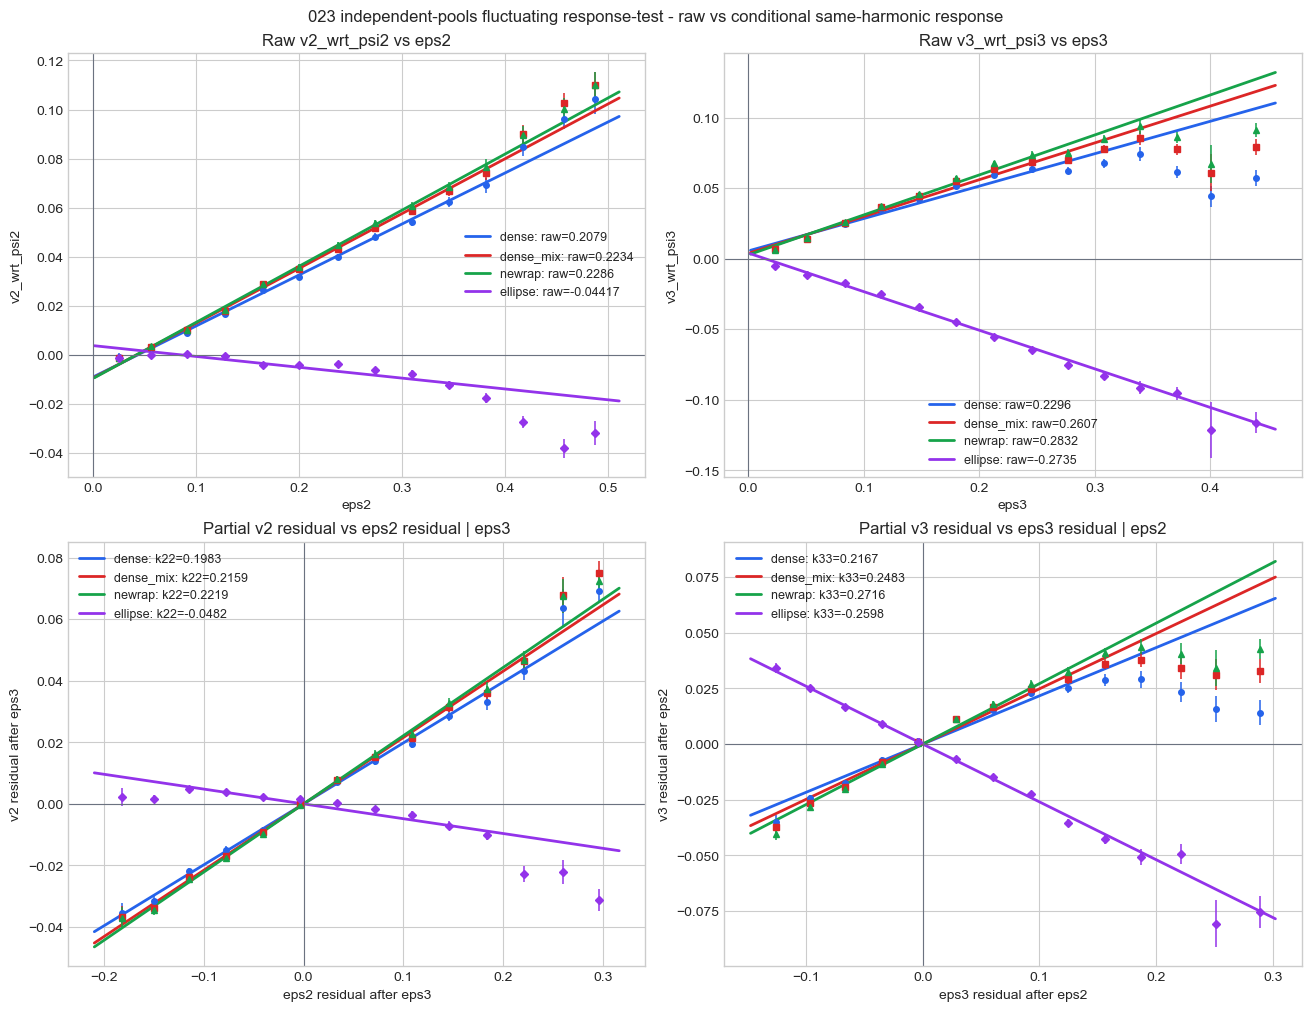

In [10]:
# Plot raw and partial-regression same-harmonic response for each source label.
STYLE_CYCLE = [
    {"color": "#2563eb", "marker": "o"},
    {"color": "#dc2626", "marker": "s"},
    {"color": "#16a34a", "marker": "^"},
    {"color": "#9333ea", "marker": "D"},
]


def draw_profile_with_line(ax, x, y, *, slope, intercept, label, style):
    mask = np.isfinite(x) & np.isfinite(y)
    x = np.asarray(x, dtype=float)[mask]
    y = np.asarray(y, dtype=float)[mask]
    if x.size == 0:
        return
    if PLOT_RAW_SCATTER:
        if x.size > SCATTER_MAX_POINTS:
            ax.hexbin(x, y, gridsize=60, mincnt=1, cmap="Greys", alpha=0.25)
        else:
            ax.scatter(x, y, s=8, alpha=0.12, linewidths=0, color=style["color"])
    profile = binned_profile(x, y, bins=PROFILE_BINS)
    if not profile.empty:
        ax.errorbar(profile["x"], profile["y"], yerr=profile["yerr"], fmt=style["marker"], color=style["color"], ms=4, lw=1.1)
    x_line = np.linspace(float(np.min(x)), float(np.max(x)), 200)
    ax.plot(x_line, intercept + slope * x_line, color=style["color"], lw=2.0, label=label)


def plot_raw_and_partial_diagonal(group):
    group_key = group["key"]
    fig, axes = plt.subplots(2, 2, figsize=(13, 10), constrained_layout=True)
    raw_v2_ax, raw_v3_ax = axes[0]
    part_v2_ax, part_v3_ax = axes[1]

    for style_index, spec in enumerate(group["input_files"]):
        label = spec["label"]
        style = STYLE_CYCLE[style_index % len(STYLE_CYCLE)]
        data = selected_events_by_group[group_key][label]
        raw = raw_fits[group_key][label]
        mv = multivariate_results[group_key][label]

        draw_profile_with_line(
            raw_v2_ax,
            data["eps2"], data["v2_wrt_psi2"],
            slope=raw["same_v2_eps2"]["slope"], intercept=raw["same_v2_eps2"]["intercept"],
            label=f"{label}: raw={raw['same_v2_eps2']['slope']:.4g}", style=style,
        )
        draw_profile_with_line(
            raw_v3_ax,
            data["eps3"], data["v3_wrt_psi3"],
            slope=raw["same_v3_eps3"]["slope"], intercept=raw["same_v3_eps3"]["intercept"],
            label=f"{label}: raw={raw['same_v3_eps3']['slope']:.4g}", style=style,
        )

        weights = weights_for(data)
        eps2_resid = residualize(data, "eps2", ["eps3"], weights=weights)
        v2_resid = residualize(data, "v2_wrt_psi2", ["eps3"], weights=weights)
        eps3_resid = residualize(data, "eps3", ["eps2"], weights=weights)
        v3_resid = residualize(data, "v3_wrt_psi3", ["eps2"], weights=weights)
        draw_profile_with_line(
            part_v2_ax,
            eps2_resid, v2_resid,
            slope=mv["v2"]["coefficients"]["eps2"], intercept=0.0,
            label=f"{label}: k22={mv['v2']['coefficients']['eps2']:.4g}", style=style,
        )
        draw_profile_with_line(
            part_v3_ax,
            eps3_resid, v3_resid,
            slope=mv["v3"]["coefficients"]["eps3"], intercept=0.0,
            label=f"{label}: k33={mv['v3']['coefficients']['eps3']:.4g}", style=style,
        )

    raw_v2_ax.set_title("Raw v2_wrt_psi2 vs eps2")
    raw_v2_ax.set_xlabel("eps2")
    raw_v2_ax.set_ylabel("v2_wrt_psi2")
    raw_v3_ax.set_title("Raw v3_wrt_psi3 vs eps3")
    raw_v3_ax.set_xlabel("eps3")
    raw_v3_ax.set_ylabel("v3_wrt_psi3")
    part_v2_ax.set_title("Partial v2 residual vs eps2 residual | eps3")
    part_v2_ax.set_xlabel("eps2 residual after eps3")
    part_v2_ax.set_ylabel("v2 residual after eps3")
    part_v3_ax.set_title("Partial v3 residual vs eps3 residual | eps2")
    part_v3_ax.set_xlabel("eps3 residual after eps2")
    part_v3_ax.set_ylabel("v3 residual after eps2")
    for ax in axes.ravel():
        ax.axhline(0.0, color="#6b7280", lw=0.8)
        ax.axvline(0.0, color="#6b7280", lw=0.8)
        ax.legend(frameon=False, fontsize=9)
    fig.suptitle(f"{group['title']} - raw vs conditional same-harmonic response")
    return fig, axes


diagonal_response_figs = {}
for group in analysis_groups:
    fig, axes = plot_raw_and_partial_diagonal(group)
    diagonal_response_figs[group["key"]] = fig
    plt.show()


## Lab-frame V2 多元诊断

这里把 `v2_lab_x` 和 `v2_lab_y` 同时对 `eps2`、`eps3` 做多元回归。它回答的是固定 lab 坐标下二阶 Q-vector 分量如何随几何变化，而不是 participant-plane 上的同阶响应系数。


In [11]:
# Fit optional lab-frame V2 components against eps2 and eps3 when the branches exist.
LAB_V2_BRANCHES = ["v2_lab_x", "v2_lab_y"]
LAB_V2_RAW_PAIRS = {
    "v2_lab_x_vs_eps2": {"epsilon": "eps2", "response": "v2_lab_x"},
    "v2_lab_y_vs_eps2": {"epsilon": "eps2", "response": "v2_lab_y"},
    "v2_lab_x_vs_eps3": {"epsilon": "eps3", "response": "v2_lab_x"},
    "v2_lab_y_vs_eps3": {"epsilon": "eps3", "response": "v2_lab_y"},
}

lab_v2_results = {}
lab_v2_raw_fits = {}
lab_v2_rows = []
lab_v2_figs = {}

for group in analysis_groups:
    group_key = group["key"]
    lab_v2_results[group_key] = {}
    lab_v2_raw_fits[group_key] = {}
    for spec in group["input_files"]:
        label = spec["label"]
        data = selected_events_by_group[group_key][label]
        if not all(branch in data.columns for branch in LAB_V2_BRANCHES):
            continue
        weights = weights_for(data)
        lab_v2_results[group_key][label] = {}
        lab_v2_raw_fits[group_key][label] = {}

        for response in LAB_V2_BRANCHES:
            fit = multivariate_fit(data, response, weights=weights)
            lab_v2_results[group_key][label][response] = fit
            response_values = data[response].to_numpy(dtype=float)
            finite_response = np.isfinite(response_values)
            lab_v2_rows.append({
                "analysis_group": group_key,
                "label": label,
                "response": response,
                "n_events": fit["n"],
                "mean_response": float(np.mean(response_values[finite_response])) if np.any(finite_response) else np.nan,
                "mean_v2": float(data["v2"].mean()) if "v2" in data else np.nan,
                "mean_v2_wrt_psi2": float(data["v2_wrt_psi2"].mean()) if "v2_wrt_psi2" in data else np.nan,
                "coeff_eps2": fit["coefficients"]["eps2"],
                "coeff_eps2_stderr": fit["stderr"]["eps2"],
                "coeff_eps3": fit["coefficients"]["eps3"],
                "coeff_eps3_stderr": fit["stderr"]["eps3"],
                "intercept": fit["intercept"],
                "r2": fit["r2"],
            })

        for fit_name, pair in LAB_V2_RAW_PAIRS.items():
            fit = linear_fit(data[pair["epsilon"]], data[pair["response"]], weights=weights, intercept=True)
            lab_v2_raw_fits[group_key][label][fit_name] = fit

lab_v2_summary = pd.DataFrame(lab_v2_rows)
if lab_v2_summary.empty:
    print("No v2_lab_x/v2_lab_y branches found; skipping lab-frame V2 multivariate diagnostics.")
else:
    display(lab_v2_summary)


,analysis_group,label,response,n_events,mean_response,mean_v2,mean_v2_wrt_psi2,coeff_eps2,coeff_eps2_stderr,coeff_eps3,coeff_eps3_stderr,intercept,r2
0,response_023_fluct_independent_pools,dense,v2_lab_x,5000,-0.027329,0.044561,0.025659,-0.194195,0.004144,0.041102,0.005397,-0.000040,0.358888
1,response_023_fluct_independent_pools,dense,v2_lab_y,5000,-0.000072,0.044561,0.025659,-0.002693,0.003829,-0.006067,0.004987,0.001118,0.000316
2,response_023_fluct_independent_pools,dense_mix,v2_lab_x,5000,-0.029701,0.045881,0.027822,-0.211185,0.004065,0.031606,0.005294,0.001576,0.397905
3,response_023_fluct_independent_pools,dense_mix,v2_lab_y,5000,-0.000036,0.045881,0.027822,-0.002281,0.003830,-0.005232,0.004988,0.000983,0.000234
4,response_023_fluct_independent_pools,newrap,v2_lab_x,5000,-0.030424,0.046019,0.028514,-0.216627,0.003952,0.028570,0.005147,0.002130,0.421127
5,response_023_fluct_independent_pools,newrap,v2_lab_y,5000,0.000099,0.046019,0.028514,-0.000930,0.003784,-0.003981,0.004928,0.000741,0.000131
6,response_023_fluct_independent_pools,ellipse,v2_lab_x,5000,0.003489,0.027922,-0.003480,0.047605,0.003448,0.014253,0.004491,-0.006176,0.037149
7,response_023_fluct_independent_pools,ellipse,v2_lab_y,5000,-0.000051,0.027922,-0.003480,-0.006253,0.003214,-0.003303,0.004186,0.001394,0.000761


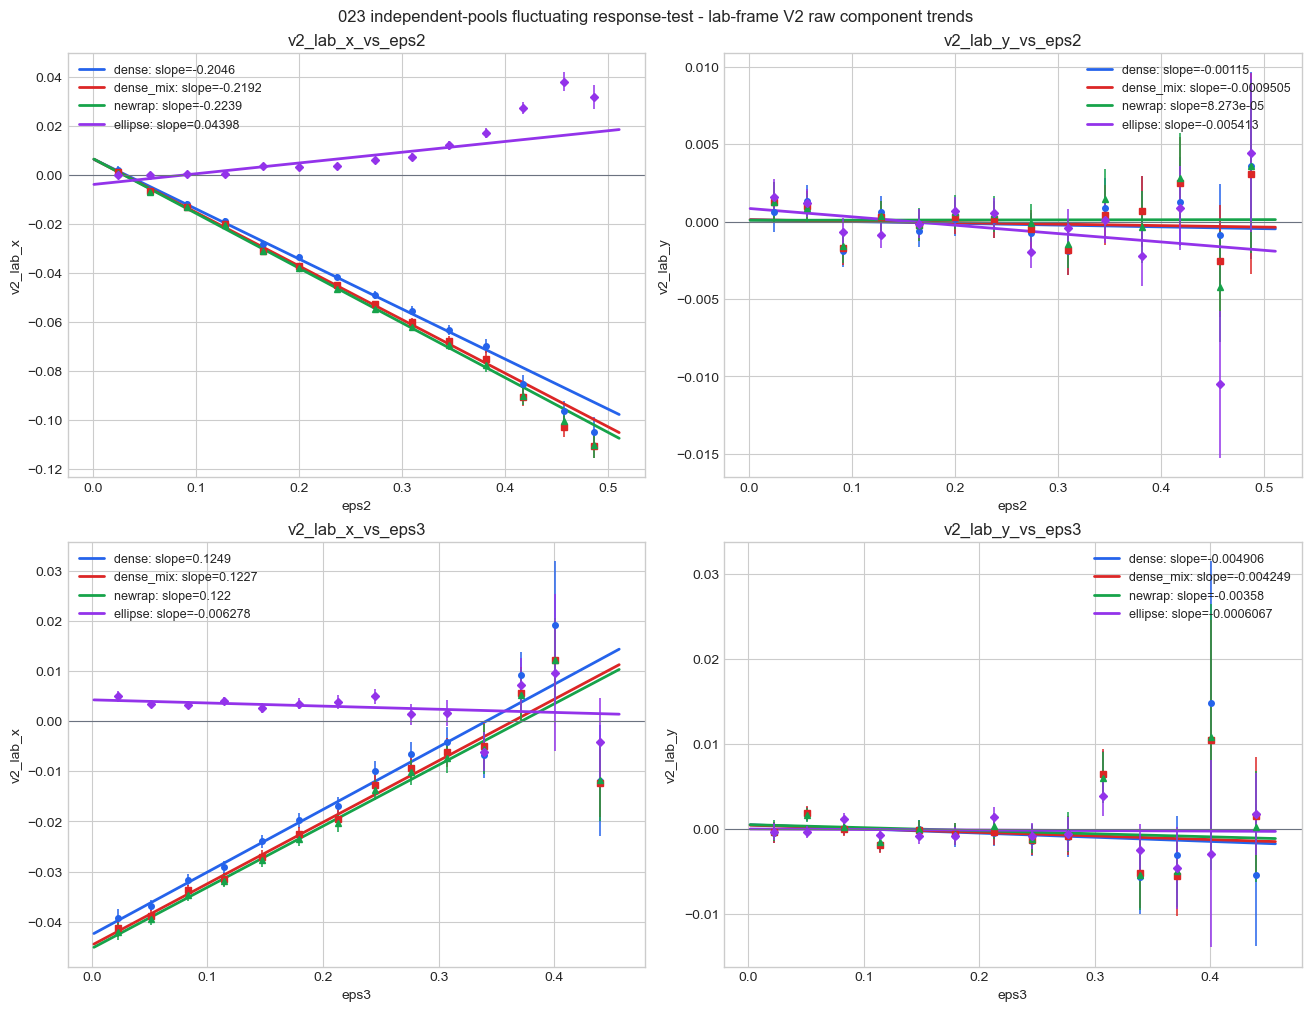

In [12]:
# Plot raw lab-frame V2 component trends for files that contain the optional branches.
def plot_lab_v2_components(group):
    group_key = group["key"]
    valid_specs = [spec for spec in group["input_files"] if spec["label"] in lab_v2_raw_fits[group_key]]
    if not valid_specs:
        return None, None

    fig, axes = plt.subplots(2, 2, figsize=(13, 10), constrained_layout=True)
    for ax, (fit_name, pair) in zip(axes.ravel(), LAB_V2_RAW_PAIRS.items()):
        for style_index, spec in enumerate(valid_specs):
            label = spec["label"]
            style = STYLE_CYCLE[style_index % len(STYLE_CYCLE)]
            data = selected_events_by_group[group_key][label]
            fit = lab_v2_raw_fits[group_key][label][fit_name]
            draw_profile_with_line(
                ax,
                data[pair["epsilon"]], data[pair["response"]],
                slope=fit["slope"], intercept=fit["intercept"],
                label=f"{label}: slope={fit['slope']:.4g}", style=style,
            )
        ax.set_title(fit_name)
        ax.set_xlabel(pair["epsilon"])
        ax.set_ylabel(pair["response"])
        ax.axhline(0.0, color="#6b7280", lw=0.8)
        ax.legend(frameon=False, fontsize=9)
    fig.suptitle(f"{group['title']} - lab-frame V2 raw component trends")
    return fig, axes


if not lab_v2_summary.empty:
    for group in analysis_groups:
        fig, axes = plot_lab_v2_components(group)
        if fig is None:
            continue
        lab_v2_figs[group["key"]] = fig
        plt.show()


## 图形检查

第一组图是 raw cross slope；第二组图是 partial-regression 图：横纵轴都已经扣除另一个 eccentricity 的线性影响，斜率对应多元回归里的条件交叉系数。


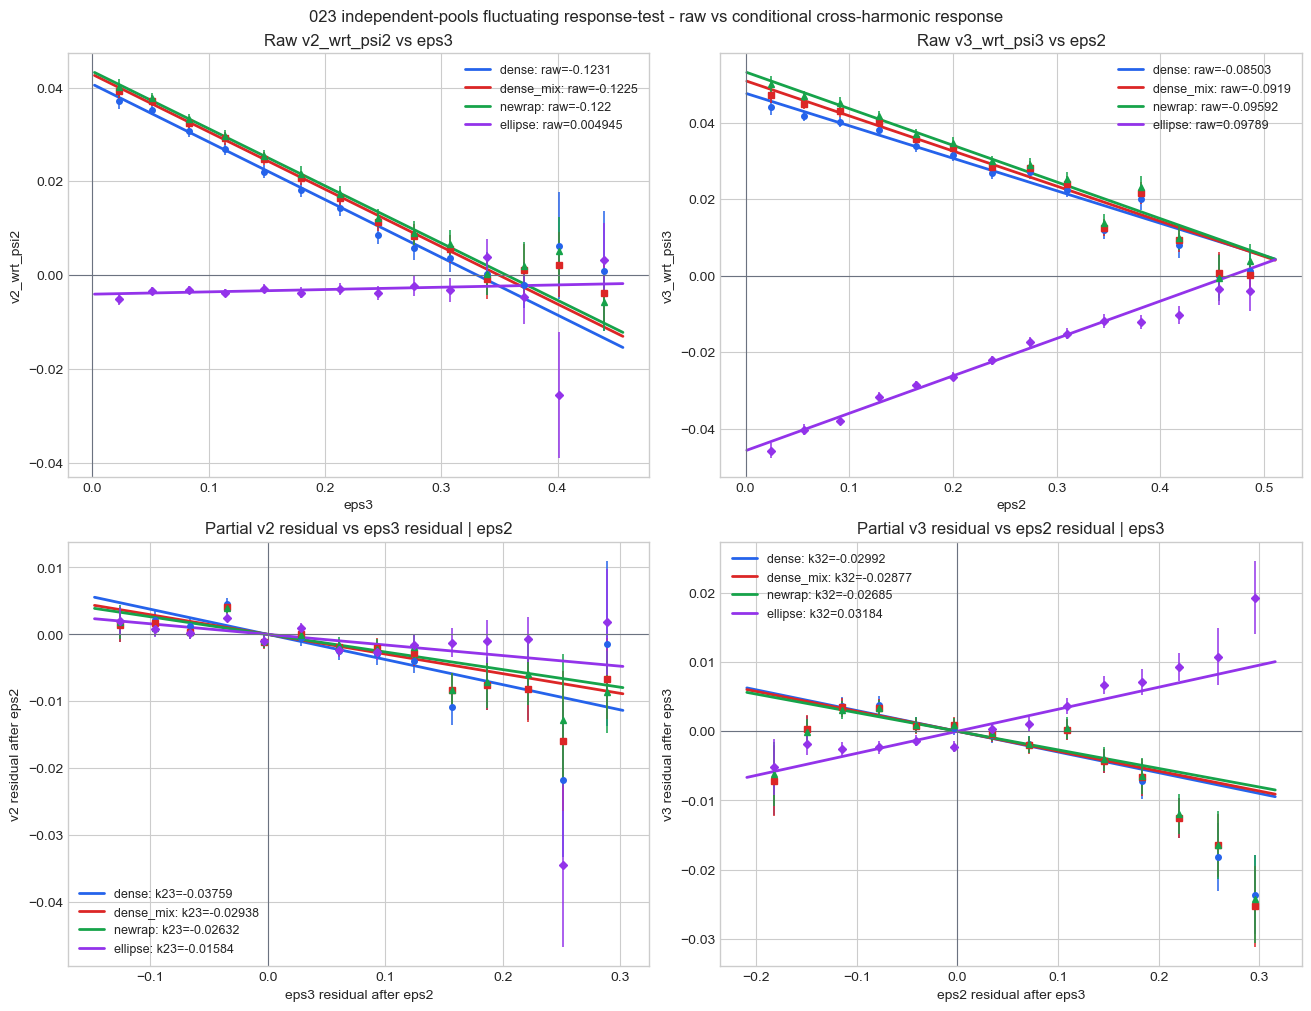

In [13]:
# Plot raw cross trends and partial-regression cross trends for each source label.
STYLE_CYCLE = [
    {"color": "#2563eb", "marker": "o"},
    {"color": "#dc2626", "marker": "s"},
    {"color": "#16a34a", "marker": "^"},
    {"color": "#9333ea", "marker": "D"},
]


def draw_profile_with_line(ax, x, y, *, slope, intercept, label, style):
    mask = np.isfinite(x) & np.isfinite(y)
    x = np.asarray(x, dtype=float)[mask]
    y = np.asarray(y, dtype=float)[mask]
    if x.size == 0:
        return
    if PLOT_RAW_SCATTER:
        if x.size > SCATTER_MAX_POINTS:
            ax.hexbin(x, y, gridsize=60, mincnt=1, cmap="Greys", alpha=0.25)
        else:
            ax.scatter(x, y, s=8, alpha=0.12, linewidths=0, color=style["color"])
    profile = binned_profile(x, y, bins=PROFILE_BINS)
    if not profile.empty:
        ax.errorbar(profile["x"], profile["y"], yerr=profile["yerr"], fmt=style["marker"], color=style["color"], ms=4, lw=1.1)
    x_line = np.linspace(float(np.min(x)), float(np.max(x)), 200)
    ax.plot(x_line, intercept + slope * x_line, color=style["color"], lw=2.0, label=label)


def plot_raw_and_partial_cross(group):
    group_key = group["key"]
    fig, axes = plt.subplots(2, 2, figsize=(13, 10), constrained_layout=True)
    raw_v2_ax, raw_v3_ax = axes[0]
    part_v2_ax, part_v3_ax = axes[1]

    for style_index, spec in enumerate(group["input_files"]):
        label = spec["label"]
        style = STYLE_CYCLE[style_index % len(STYLE_CYCLE)]
        data = selected_events_by_group[group_key][label]
        raw = raw_fits[group_key][label]
        mv = multivariate_results[group_key][label]

        draw_profile_with_line(
            raw_v2_ax,
            data["eps3"], data["v2_wrt_psi2"],
            slope=raw["raw_cross_v2_eps3"]["slope"], intercept=raw["raw_cross_v2_eps3"]["intercept"],
            label=f"{label}: raw={raw['raw_cross_v2_eps3']['slope']:.4g}", style=style,
        )
        draw_profile_with_line(
            raw_v3_ax,
            data["eps2"], data["v3_wrt_psi3"],
            slope=raw["raw_cross_v3_eps2"]["slope"], intercept=raw["raw_cross_v3_eps2"]["intercept"],
            label=f"{label}: raw={raw['raw_cross_v3_eps2']['slope']:.4g}", style=style,
        )

        weights = weights_for(data)
        eps3_resid = residualize(data, "eps3", ["eps2"], weights=weights)
        v2_resid = residualize(data, "v2_wrt_psi2", ["eps2"], weights=weights)
        eps2_resid = residualize(data, "eps2", ["eps3"], weights=weights)
        v3_resid = residualize(data, "v3_wrt_psi3", ["eps3"], weights=weights)
        draw_profile_with_line(
            part_v2_ax,
            eps3_resid, v2_resid,
            slope=mv["v2"]["coefficients"]["eps3"], intercept=0.0,
            label=f"{label}: k23={mv['v2']['coefficients']['eps3']:.4g}", style=style,
        )
        draw_profile_with_line(
            part_v3_ax,
            eps2_resid, v3_resid,
            slope=mv["v3"]["coefficients"]["eps2"], intercept=0.0,
            label=f"{label}: k32={mv['v3']['coefficients']['eps2']:.4g}", style=style,
        )

    raw_v2_ax.set_title("Raw v2_wrt_psi2 vs eps3")
    raw_v2_ax.set_xlabel("eps3")
    raw_v2_ax.set_ylabel("v2_wrt_psi2")
    raw_v3_ax.set_title("Raw v3_wrt_psi3 vs eps2")
    raw_v3_ax.set_xlabel("eps2")
    raw_v3_ax.set_ylabel("v3_wrt_psi3")
    part_v2_ax.set_title("Partial v2 residual vs eps3 residual | eps2")
    part_v2_ax.set_xlabel("eps3 residual after eps2")
    part_v2_ax.set_ylabel("v2 residual after eps2")
    part_v3_ax.set_title("Partial v3 residual vs eps2 residual | eps3")
    part_v3_ax.set_xlabel("eps2 residual after eps3")
    part_v3_ax.set_ylabel("v3 residual after eps3")
    for ax in axes.ravel():
        ax.axhline(0.0, color="#6b7280", lw=0.8)
        ax.axvline(0.0, color="#6b7280", lw=0.8)
        ax.legend(frameon=False, fontsize=9)
    fig.suptitle(f"{group['title']} - raw vs conditional cross-harmonic response")
    return fig, axes


cross_response_figs = {}
for group in analysis_groups:
    fig, axes = plot_raw_and_partial_cross(group)
    cross_response_figs[group["key"]] = fig
    plt.show()


## 可选：保存表格和图

默认不写文件。需要把结果落盘时，把 `SAVE_OUTPUTS` 改成 `True`。执行验证时 notebook 本身会保留表格输出。

In [14]:
# Persist compact regression summaries and figures only when explicitly requested.
SAVE_OUTPUTS = False
OUTPUT_DIR = PROJECT_ROOT / "qa" / "vn_epsn_multivariate_regression"

if SAVE_OUTPUTS:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    inspection_table.to_csv(OUTPUT_DIR / "inspection_summary.csv", index=False)
    read_summary.to_csv(OUTPUT_DIR / "read_summary.csv", index=False)
    selection_summary.to_csv(OUTPUT_DIR / "selection_summary.csv", index=False)
    geometry_summary.to_csv(OUTPUT_DIR / "geometry_summary.csv", index=False)
    raw_fit_summary.to_csv(OUTPUT_DIR / "raw_fit_summary.csv", index=False)
    multivariate_summary.to_csv(OUTPUT_DIR / "multivariate_summary.csv", index=False)
    decomposition_summary.to_csv(OUTPUT_DIR / "decomposition_summary.csv", index=False)
    diagonal_summary.to_csv(OUTPUT_DIR / "diagonal_summary.csv", index=False)
    if not lab_v2_summary.empty:
        lab_v2_summary.to_csv(OUTPUT_DIR / "lab_v2_multivariate_summary.csv", index=False)
    for group in analysis_groups:
        diagonal_response_figs[group["key"]].savefig(OUTPUT_DIR / f"{group['key']}_raw_vs_partial_same_harmonic_response.png", dpi=160)
        cross_response_figs[group["key"]].savefig(OUTPUT_DIR / f"{group['key']}_raw_vs_partial_cross_response.png", dpi=160)
        if group["key"] in lab_v2_figs:
            lab_v2_figs[group["key"]].savefig(OUTPUT_DIR / f"{group['key']}_lab_v2_components.png", dpi=160)
    print(f"Saved multivariate regression tables and figures under {OUTPUT_DIR}")
else:
    print("SAVE_OUTPUTS is False; no files were written.")


SAVE_OUTPUTS is False; no files were written.
